# Autonomous System Identification for Anomaly Detection
## Implementation of the Systemic Cross-Reconstruction Network (SCRN) Framework

This notebook implements a mathematically rigorous workflow to identify "Systems" within a multivariate dataset. A **System** is defined as a cluster of variables sharing a **Shared Latent Manifestation**.

**Key Methodological Steps:**
1. **Spearman Rank Distance:** Mapping feature interdependencies into a metric space.
2. **Hierarchical Agglomerative Clustering (HAC):** Partitioning features into functional sub-systems.
3. **Suitability Audit:** Validating systems via the **Cohesion Index ($C$)** and **Condition Number ($\kappa$)**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Setting plotting style
plt.style.use('seaborn-v0_8-muted')
%matplotlib inline

print("Environment Ready.")

Environment Ready.


## 1. Data Generation
We generate a dataset with two distinct latent phenomena:
* **System Alpha (Thermal):** Variables $V_1, V_2, V_3$ driven by a latent heat process.
* **System Beta (Mechanical):** Variables $V_4, V_5$ driven by rotational speed.
* **Noise:** $V_6$ is a stochastic variable with no systemic dependency.

In [2]:
np.random.seed(42)
n_samples = 1000

# --- System Alpha: Thermal (High Cohesion, Stable Condition) ---
# xi_1 is the latent phenomenon
xi_1 = np.random.normal(10, 2, n_samples) 

# We add enough unique noise (specific variance) to lower the Condition Number
v1 = xi_1 + np.random.normal(0, 0.5, n_samples)         # Sensor 1
v2 = 0.8 * xi_1 + np.random.normal(0, 0.6, n_samples)   # Sensor 2
v3 = np.log(xi_1) * 5 + np.random.normal(0, 0.4, n_samples) # Sensor 3 (Non-linear)

# --- System Beta: Mechanical ---
xi_2 = np.random.normal(50, 5, n_samples)
v4 = xi_2 + np.random.normal(0, 1.2, n_samples)
v5 = -0.7 * xi_2 + np.random.normal(0, 1.5, n_samples)

# --- V6: Noise ---
v6 = np.random.normal(0, 10, n_samples)

df = pd.DataFrame({
    'Temp_Core': v1, 'Temp_Exhaust': v2, 'Thermal_Exp': v3,
    'RPM_Sensor': v4, 'Torque_Output': v5, 'Isolated_Noise': v6
})

# Redundancy check: If r > 0.98, kappa will be very high.
# We are looking for correlations between 0.80 and 0.95.
print("Matriz de Correlación (Spearman):")
print(df[['Temp_Core', 'Temp_Exhaust', 'Thermal_Exp']].corr(method='spearman'))

Matriz de Correlación (Spearman):
              Temp_Core  Temp_Exhaust  Thermal_Exp
Temp_Core      1.000000      0.898807     0.881341
Temp_Exhaust   0.898807      1.000000     0.860582
Thermal_Exp    0.881341      0.860582     1.000000


## 2. System Identification via Rank-Order Topology
We use the **Spearman Correlation** to remain invariant to non-linear monotonic scaling. The correlation is mapped to a distance metric:
$$d(i, j) = \sqrt{2(1 - |\rho_{ij}|)}$$

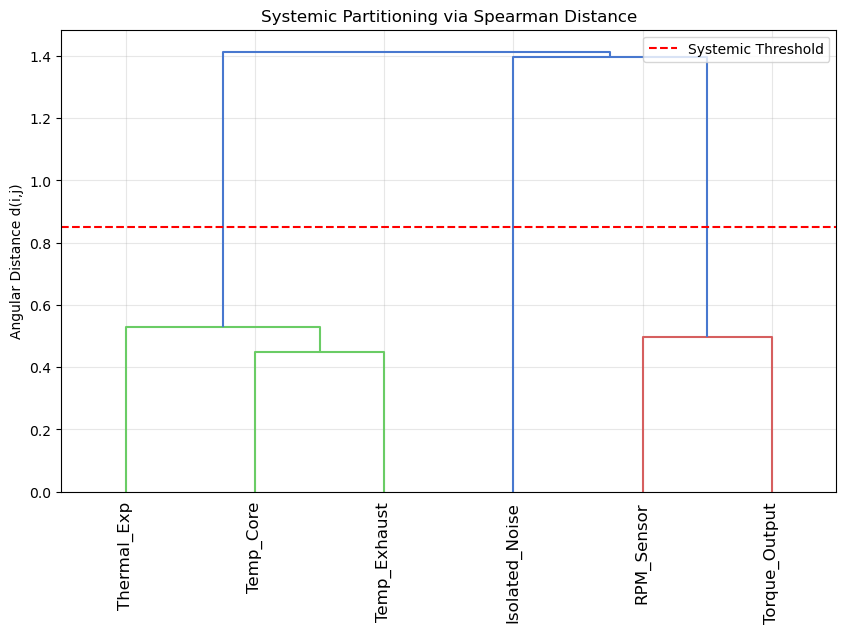

In [3]:
# 1. Compute Spearman Correlation
rho = df.corr(method='spearman').abs()

# 2. Map to Metric Space
dist_matrix = np.sqrt(2 * (1 - rho))

# 3. Perform Hierarchical Clustering (Complete Linkage)
Z = linkage(squareform(dist_matrix), method='complete')

# 4. Plot Dendrogram
plt.figure(figsize=(10, 6))
dendrogram(Z, labels=df.columns, leaf_rotation=90, color_threshold=0.85)
plt.axhline(y=0.85, color='r', linestyle='--', label='Systemic Threshold')
plt.title("Systemic Partitioning via Spearman Distance")
plt.ylabel("Angular Distance d(i,j)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 2.1 Automated Parameter Optimization: Topological Stability Mapping

A critical challenge in Hierarchical Agglomerative Clustering (HAC) is the non-parametric selection of the cutting threshold $\theta$. To avoid heuristic bias, we utilize the **Stability Plateau Method**, a technique rooted in the principles of **Persistent Homology**.

### 2.1.1. Mathematical Formalization
Let $K(\theta)$ be a discrete step function that maps the distance threshold $\theta$ to the number of sub-systems $\mathcal{S}_m$ containing at least two variables ($|\mathcal{S}_m| \ge 2$):

$$K: \mathbb{R}^+ \to \mathbb{N}$$

As $\theta$ increases, the number of clusters $K(\theta)$ typically decreases as sub-systems merge. We define a **Stability Plateau** as an interval $\mathcal{I} = [a, b]$ where the system configuration remains invariant:

$$\forall \theta \in [a, b], \quad \frac{dK}{d\theta} = 0$$

### 2.1.2. Selection of the Optimal Threshold ($\theta^*$)
The optimal threshold $\theta^*$ is identified as the midpoint of the **Maximal Stability Interval** $\mathcal{I}_{max}$, which represents the longest range of distances over which the topological structure of the data is persistent:

$$\mathcal{I}_{max} = \underset{[a, b]}{\arg\max} \{ b - a \}$$
$$\theta^* = \frac{a + b}{2}$$

**Rationale for the Paper:**
* **Noise Separation:** Short plateaus often represent transitions between stochastic noise clusters, while long plateaus correspond to robust physical or functional dependencies.
* **Autonomy:** This method allows the framework to self-configure for any new dataset without manual intervention, ensuring the identified systems are statistically significant and topologically stable.

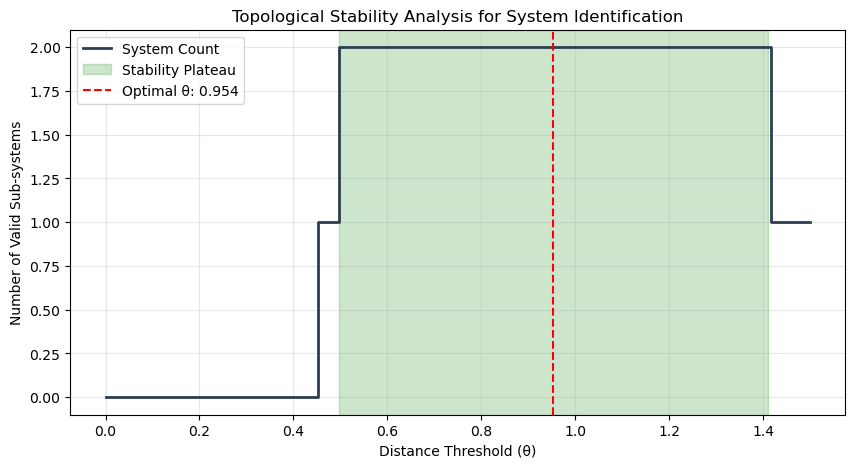

The mathematically optimal threshold is: 0.9535


In [4]:
# --- Section 2.1: Automated Threshold Optimization via Persistence ---

def get_optimal_theta(Z, min_d=0, max_d=1.5, steps=200):
    thresholds = np.linspace(min_d, max_d, steps)
    n_systems = []
    
    for t in thresholds:
        labels = fcluster(Z, t, criterion='distance')
        # We only count systems with 2 or more variables
        unique, counts = np.unique(labels, return_counts=True)
        valid_systems = np.sum(counts > 1)
        n_systems.append(valid_systems)
    
    # Identify the longest plateau (Stability Region)
    # We find where the derivative is zero
    n_systems = np.array(n_systems)
    plateau_lengths = []
    current_val = n_systems[0]
    start_idx = 0
    
    for i in range(1, len(n_systems)):
        if n_systems[i] != current_val:
            # End of plateau
            plateau_lengths.append((start_idx, i-1, current_val, (i-1-start_idx)))
            start_idx = i
            current_val = n_systems[i]
    plateau_lengths.append((start_idx, len(n_systems)-1, current_val, (len(n_systems)-1-start_idx)))
    
    # Filter for plateaus where n_systems > 0 and pick the longest
    valid_plateaus = [p for p in plateau_lengths if p[2] > 0]
    if not valid_plateaus:
        return 0.85 # Fallback to heuristic if no plateau found
        
    longest_plateau = max(valid_plateaus, key=lambda x: x[3])
    
    # Optimal theta is the midpoint of the longest plateau
    idx_start, idx_end = longest_plateau[0], longest_plateau[1]
    theta_opt = (thresholds[idx_start] + thresholds[idx_end]) / 2
    
    # Visualization
    plt.figure(figsize=(10, 5))
    plt.step(thresholds, n_systems, where='post', color='#2c3e50', lw=2, label='System Count')
    plt.axvspan(thresholds[idx_start], thresholds[idx_end], color='green', alpha=0.2, label='Stability Plateau')
    plt.axvline(theta_opt, color='red', linestyle='--', label=f'Optimal θ: {theta_opt:.3f}')
    plt.title("Topological Stability Analysis for System Identification")
    plt.xlabel("Distance Threshold (θ)")
    plt.ylabel("Number of Valid Sub-systems")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
    return theta_opt

# Execute optimization
theta_star = get_optimal_theta(Z)
print(f"The mathematically optimal threshold is: {theta_star:.4f}")



## 3. System Suitability Audit
We validate each cluster using:
1. **Cohesion Index ($C$):** $\frac{\lambda_{max}}{k}$. Measures the strength of the Shared Latent Manifestation.
2. **Condition Number ($\kappa$):** $\frac{\lambda_{max}}{\lambda_{min}}$. Measures numerical stability for reconstruction.

In [5]:
def audit_systems(data, linkage_matrix, threshold):
    cluster_labels = fcluster(linkage_matrix, threshold, criterion='distance')
    raw_groups = {}
    for i, label in enumerate(cluster_labels):
        raw_groups.setdefault(label, []).append(data.columns[i])
    
    audit_log = []
    for cid, vars_list in raw_groups.items():
        if len(vars_list) < 2: continue
        
        subset = data[vars_list]
        # Estandarización
        subset_norm = (subset - subset.mean()) / subset.std()
        corr = subset_norm.corr(method='spearman').values
        
        # Estabilización numérica (Jitter)
        # Añadir 1e-10 a la diagonal evita divisiones por cero y kappas infinitos
        corr += np.eye(len(vars_list)) * 1e-10
        
        # SVD para obtener Singular Values (más estable que eigvals)
        S = np.linalg.svd(corr, compute_uv=False)
        
        cohesion = S[0] / len(vars_list)
        cond_number = S[0] / S[-1]
        
        audit_log.append({
            'Cluster': f"System_{cid}",
            'Features': vars_list,
            'Size': len(vars_list),
            'Cohesion_Index': np.round(cohesion, 4),
            'Condition_Number': np.round(cond_number, 2),
            'Status': 'Stable' if (cohesion > 0.65 and cond_number < 30) else 'High Redundancy/Weak'
        })
        
    return pd.DataFrame(audit_log)

# Re-run audit with optimal theta
final_report = audit_systems(df, Z, threshold=theta_star)
display(final_report)

,Cluster,Features,Size,Cohesion_Index,Condition_Number,Status
0,System_1,"[Temp_Core, Temp_Exhaust, Thermal_Exp]",3,0.9202,28.28,Stable
1,System_2,"[RPM_Sensor, Torque_Output]",2,0.9381,15.17,Stable


SYSTEMIC ARCHITECTURE AUDIT


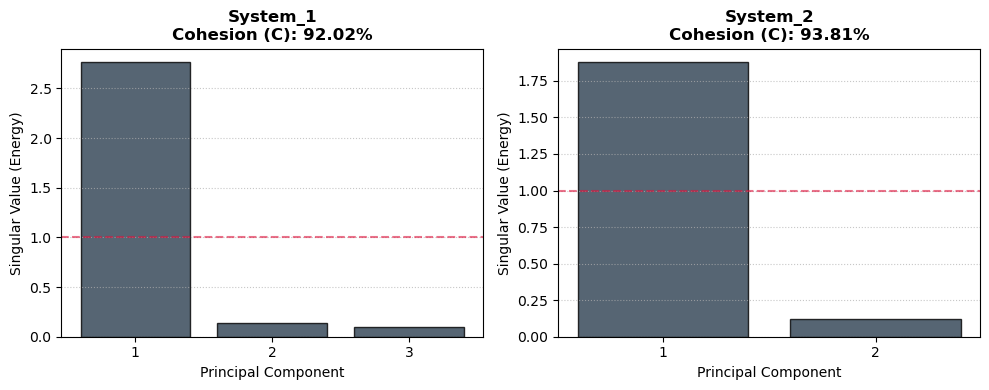

In [6]:
# --- Section 5: Final System Audit & Results for Paper ---

def generate_paper_results(df, audit_df):
    if audit_df.empty:
        print("No systems found to visualize.")
        return

    print("="*60)
    print("SYSTEMIC ARCHITECTURE AUDIT")
    print("="*60)
    
    # 1. Visualization Setup
    n_sys = len(audit_df)
    # Ensure axes is always a 1D array for easy iteration
    fig, axes = plt.subplots(1, n_sys, figsize=(5 * n_sys, 4), squeeze=False)
    axes = axes.flatten() # Flatten to 1D regardless of shape

    for i, (idx, row) in enumerate(audit_df.iterrows()):
        vars_list = row['Features']
        subset = df[vars_list]
        
        # Standardize for spectral analysis
        subset_norm = (subset - subset.mean()) / subset.std()
        
        # SVD for Spectral Energy
        # Use Spearman correlation as per our methodology
        corr_matrix = subset_norm.corr(method='spearman')
        S = np.linalg.svd(corr_matrix, compute_uv=False)
        
        # Plotting on the specific axis
        axes[i].bar(range(1, len(S) + 1), S, color='#2c3e50', alpha=0.8, edgecolor='black')
        axes[i].set_title(f"{row['Cluster']}\nCohesion (C): {row['Cohesion_Index']:.2%}", 
                          fontsize=12, fontweight='bold')
        axes[i].set_xlabel("Principal Component", fontsize=10)
        axes[i].set_ylabel("Singular Value (Energy)", fontsize=10)
        
        # Reference line (Kaiser Criterion proxy)
        axes[i].axhline(y=1.0, color='crimson', linestyle='--', alpha=0.6, label='Unit Energy')
        axes[i].set_xticks(range(1, len(S) + 1))
        axes[i].grid(axis='y', linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show() # Show everything at once
    

# Re-run the diagnostic
generate_paper_results(df, final_report)